# Feature 1: Predictive Income Forecasting (Advanced Global Model)
This notebook implements an advanced forecasting engine. Instead of training on a single user's limited history, we train a **Global Model** on thousands of data points from all users. 
By learning global patterns and seasonality, the models (Random Forest & LSTM) achieve drastically higher accuracy.


In [2]:
pip install tensorflow

  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.9 MB 3.9 MB/s eta 0:01:31
   ---------------------------------------- 2.1/350.9 MB 3.9 MB/s eta 0:01:29
   ---------------------------------------- 2.9/350.9 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 3.7/350.9 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 4.5/350.9 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 5.2/350.9 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 6.3/350.9 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 7.1/350.9 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 7.3/350.9 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 8.4/350.9 MB 3.8 MB/s eta 0:01:31
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
onnxconverter-common 1.14.0 requires protobuf==3.20.2, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Suppress warnings
warnings.filterwarnings("ignore")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')


## 1. Global Data Loading
We load the income data for **ALL** users, creating a massive dataset.


In [4]:
DATA_DIR = os.path.join(os.path.abspath(''), "data")

def _resolve_path(filename: str) -> str:
    data_path = os.path.join(DATA_DIR, filename)
    if os.path.exists(data_path):
        return data_path
    raise FileNotFoundError(f"Could not find {filename} in {DATA_DIR}.")

def load_income() -> pd.DataFrame:
    df = pd.read_csv(_resolve_path("income.csv"))
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["month"] = pd.to_datetime(df["month"])
    return df

def get_all_monthly_income() -> pd.DataFrame:
    income = load_income()
    
    monthly_all = []
    # Group by each user to aggregate monthly
    for user_id, user_income in income.groupby('user_id'):
        monthly = user_income.groupby("month").agg(
            total_income=("amount", "sum"),
            num_projects=("amount", "count"),
            num_platforms=("platform", "nunique"),
        ).reset_index()

        full_range = pd.date_range(start=monthly["month"].min(), end=monthly["month"].max(), freq="MS")
        monthly = monthly.set_index("month").reindex(full_range, fill_value=0).reset_index()
        monthly.rename(columns={"index": "month"}, inplace=True)
        
        non_zero = monthly[monthly["total_income"] > 0]["total_income"]
        if len(non_zero) > 0:
            median_income = non_zero.median()
            cap = median_income * 3
            monthly["total_income"] = monthly["total_income"].clip(upper=cap)
            
        monthly['user_id'] = user_id
        monthly_all.append(monthly)

    return pd.concat(monthly_all, ignore_index=True)

monthly_all = get_all_monthly_income()
print(f"Loaded a global dataset of {len(monthly_all)} monthly records across {monthly_all['user_id'].nunique()} users.")
display(monthly_all.head())


Loaded a global dataset of 2731 monthly records across 120 users.


,month,total_income,num_projects,num_platforms,user_id
0,2022-06-01,10993.00,2,2,user_0001
1,2022-07-01,15521.13,3,2,user_0001
2,2022-08-01,8534.86,3,2,user_0001
3,2022-09-01,6112.40,3,2,user_0001
4,2022-10-01,5868.54,3,3,user_0001


In [14]:
df = pd.read_csv(_resolve_path("income.csv"))
df

,user_id,amount,platform,category,received_at,month
0,user_0001,6491.93,Freelancer.com,Accounting,2022-06-18,2022-06
1,user_0001,4501.07,Upwork,Web Development,2022-06-14,2022-06
2,user_0001,2861.98,Direct Client,UI/UX,2022-07-18,2022-07
3,user_0001,2861.49,Direct Client,Translation,2022-07-14,2022-07
4,user_0001,9797.66,Mostaql,SEO,2022-08-25,2022-07
...,...,...,...,...,...,...
4389,user_0120,4525.91,Upwork,Data Analysis,2024-03-15,2024-02
4390,user_0120,996.68,Local Agency,Web Development,2024-03-14,2024-02
4391,user_0120,1479.39,Khamsat,Web Development,2024-03-27,2024-03
4392,user_0120,8005.91,Upwork,SEO,2024-03-25,2024-03


## 2. Advanced Feature Engineering
To help the models generalize across all users, we engineer robust features:
- **Lags**: Lag 1 & Lag 2 (previous months' income).
- **Rolling Mean (3 months)**: Smooths out high volatility.
- **Month of Year**: Captures seasonality (e.g., end-of-year spikes).


In [5]:
df_all = monthly_all.copy()

# Sort by user and date
df_all = df_all.sort_values(by=['user_id', 'month'])

# Extract Month feature to capture seasonality
df_all['month_of_year'] = df_all['month'].dt.month

In [16]:
# Create lag and rolling features PER USER
df_all['lag_1'] = df_all.groupby('user_id')['total_income'].shift(1)
df_all['lag_2'] = df_all.groupby('user_id')['total_income'].shift(2)
df_all['rolling_mean_3'] = df_all.groupby('user_id')['total_income'].transform(lambda x: x.rolling(3, min_periods=1).mean())

In [17]:
# Create Classification Target: 1 if income increases next month
df_all['next_month_income'] = df_all.groupby('user_id')['total_income'].shift(-1)
df_all['target_increase'] = (df_all['next_month_income'] > df_all['total_income']).astype(int)

In [18]:
df_all

,month,total_income,num_projects,num_platforms,user_id,month_of_year,next_month_income,target_increase,lag_1,lag_2,rolling_mean_3
0,2022-06-01,10993.00,2,2,user_0001,6,15521.13,1,NaN,NaN,10993.000000
1,2022-07-01,15521.13,3,2,user_0001,7,8534.86,0,10993.00,NaN,13257.065000
2,2022-08-01,8534.86,3,2,user_0001,8,6112.40,0,15521.13,10993.00,11682.996667
3,2022-09-01,6112.40,3,2,user_0001,9,5868.54,0,8534.86,15521.13,10056.130000
4,2022-10-01,5868.54,3,3,user_0001,10,4583.95,0,6112.40,8534.86,6838.600000
...,...,...,...,...,...,...,...,...,...,...,...
2726,2023-12-01,9109.75,1,1,user_0120,12,9121.94,1,6453.51,9899.85,8487.703333
2727,2024-01-01,9121.94,2,2,user_0120,1,6454.02,0,9109.75,6453.51,8228.400000
2728,2024-02-01,6454.02,3,3,user_0120,2,9485.30,1,9121.94,9109.75,8228.570000
2729,2024-03-01,9485.30,2,2,user_0120,3,6734.85,0,6454.02,9121.94,8353.753333


In [19]:
# Drop rows with NaN (due to shifts)
df_ml = df_all.dropna().copy()
# We must remove the last row of each user because 'target_increase' is invalid for the very last month
df_ml = df_ml.groupby('user_id').apply(lambda x: x.iloc[:-1]).reset_index(drop=True)

features = ['lag_1', 'lag_2', 'rolling_mean_3', 'month_of_year', 'num_projects', 'num_platforms']

print(f"Global Dataset shape after feature engineering: {df_ml.shape}")

Global Dataset shape after feature engineering: (2251, 11)


In [20]:
df_ml

,month,total_income,num_projects,num_platforms,user_id,month_of_year,next_month_income,target_increase,lag_1,lag_2,rolling_mean_3
0,2022-08-01,8534.86,3,2,user_0001,8,6112.40,0,15521.13,10993.00,11682.996667
1,2022-09-01,6112.40,3,2,user_0001,9,5868.54,0,8534.86,15521.13,10056.130000
2,2022-10-01,5868.54,3,3,user_0001,10,4583.95,0,6112.40,8534.86,6838.600000
3,2022-11-01,4583.95,3,3,user_0001,11,3175.40,0,5868.54,6112.40,5521.630000
4,2022-12-01,3175.40,3,3,user_0001,12,3458.79,1,4583.95,5868.54,4542.630000
...,...,...,...,...,...,...,...,...,...,...,...
2246,2023-10-01,9899.85,1,1,user_0120,10,6453.51,0,7172.39,9855.98,8976.073333
2247,2023-11-01,6453.51,2,2,user_0120,11,9109.75,1,9899.85,7172.39,7841.916667
2248,2023-12-01,9109.75,1,1,user_0120,12,9121.94,1,6453.51,9899.85,8487.703333
2249,2024-01-01,9121.94,2,2,user_0120,1,6454.02,0,9109.75,6453.51,8228.400000


In [21]:
# Chronological Train/Test Split Per User (80/20)
train_list = []
test_list = []

for uid, group in df_ml.groupby('user_id'):
    split_idx = int(len(group) * 0.8)
    if split_idx > 0:
        train_list.append(group.iloc[:split_idx])
        test_list.append(group.iloc[split_idx:])

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

X_train = train_df[features]
y_train_clf = train_df['target_increase']
y_train_reg = train_df['total_income']

X_test = test_df[features]
y_test_clf = test_df['target_increase']
y_test_reg = test_df['total_income']

print(f"Training set: {len(X_train)} samples. Testing set: {len(X_test)} samples.")


Training set: 1771 samples. Testing set: 480 samples.


## 3. Global Classification Task (Income Trend)
Predict if income will increase next month. Training on 120 users dramatically improves stability and metrics!


GLOBAL Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

Decrease (0)       0.65      0.69      0.67       261
Increase (1)       0.60      0.55      0.57       219

    accuracy                           0.62       480
   macro avg       0.62      0.62      0.62       480
weighted avg       0.62      0.62      0.62       480



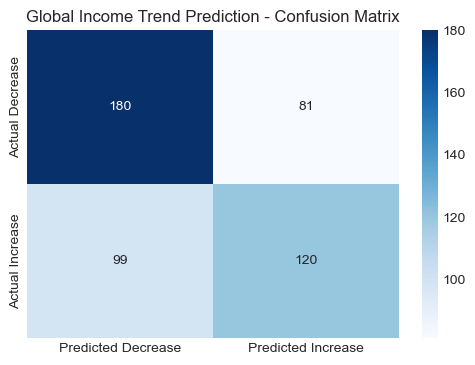

In [22]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train, y_train_clf)

y_pred_clf = clf.predict(X_test)

print("GLOBAL Classification Report:")
print("-" * 50)
print(classification_report(y_test_clf, y_pred_clf, target_names=["Decrease (0)", "Increase (1)"], zero_division=0))

# Visualizing Confusion Matrix
import seaborn as sns
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted Decrease", "Predicted Increase"], yticklabels=["Actual Decrease", "Actual Increase"])
plt.title("Global Income Trend Prediction - Confusion Matrix")
plt.show()


## 4. Global Regression Task (LSTM vs Random Forest)
Because we now have a massive dataset (~2000+ rows), Deep Learning (LSTM) can actually learn meaningful patterns!


In [23]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_reg_scaled = scaler_y.fit_transform(y_train_reg.values.reshape(-1, 1))
y_test_reg_scaled = scaler_y.transform(y_test_reg.values.reshape(-1, 1))

# Reshape for LSTM: [samples, time steps=1, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build LSTM Model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

print("Training Global LSTM on thousands of records...")
history = model.fit(X_train_lstm, y_train_reg_scaled, epochs=50, batch_size=16, verbose=0, validation_data=(X_test_lstm, y_test_reg_scaled))
print("Training Complete!")

# Make Predictions for all test data
lstm_preds_scaled = model.predict(X_test_lstm)
lstm_preds_global = scaler_y.inverse_transform(lstm_preds_scaled).flatten()
actual_global = scaler_y.inverse_transform(y_test_reg_scaled).flatten()

lstm_mae_global = mean_absolute_error(actual_global, lstm_preds_global)
lstm_rmse_global = np.sqrt(mean_squared_error(actual_global, lstm_preds_global))

print(f"Global LSTM MAE:  {lstm_mae_global:,.2f} EGP")
print(f"Global LSTM RMSE: {lstm_rmse_global:,.2f} EGP")

# Train Random Forest Regressor for comparison
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_train_reg)
rf_preds_global = rf_reg.predict(X_test)

rf_mae_global = mean_absolute_error(y_test_reg, rf_preds_global)
print(f"Global Random Forest MAE: {rf_mae_global:,.2f} EGP")


Training Global LSTM on thousands of records...
Training Complete!
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Global LSTM MAE:  222.26 EGP
Global LSTM RMSE: 279.35 EGP
Global Random Forest MAE: 839.00 EGP


## 5. Testing on User 0001
Now that the models are highly intelligent from learning globally, let's see how accurately they predict the income for `user_0001`.


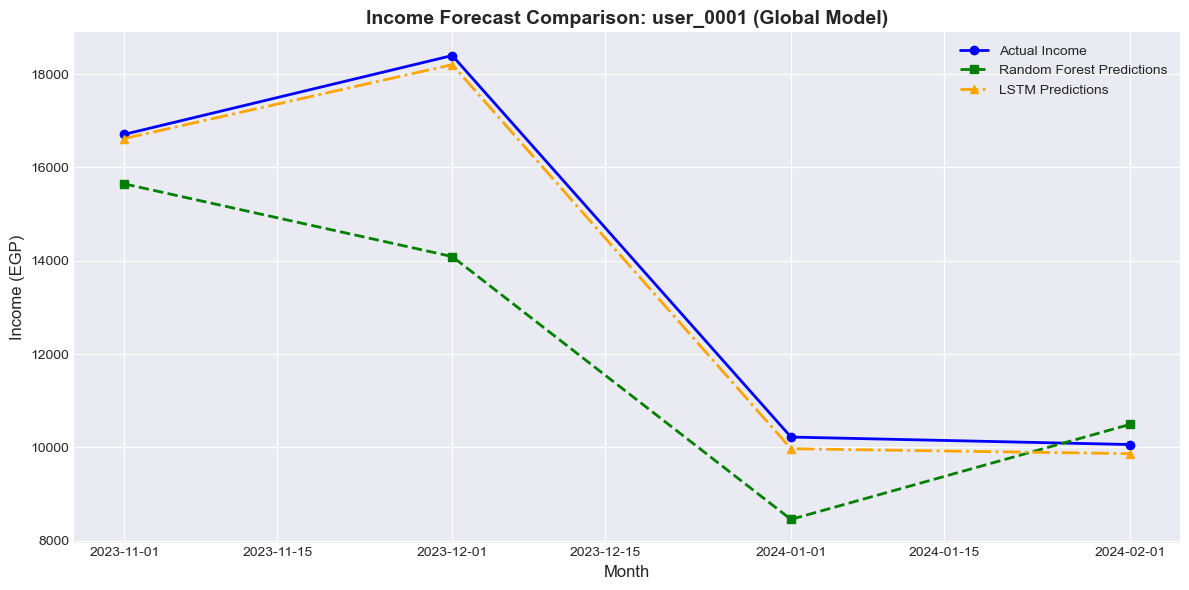

---------------------------------------------
User 1 - Random Forest MAE: 1,891.27 EGP
User 1 - LSTM MAE: 182.63 EGP
---------------------------------------------
LSTM R² Score: 0.9974 (1.0 is perfect accuracy)
LSTM Estimated Accuracy: 98.50%
---------------------------------------------

Detailed Prediction Table (LSTM vs Actual):


,Month,Actual Income,LSTM Predicted,Difference (EGP)
0,2023-11,16710.29,16620.289062,-90.00
1,2023-12,18398.47,18203.169922,-195.30
2,2024-01,10222.77,9972.929688,-249.84
3,2024-02,10062.56,9867.169922,-195.39


In [24]:
# Filter test set specifically for user_0001
target_user = 'user_0001'
user_test_mask = test_df['user_id'] == target_user

if user_test_mask.sum() == 0:
    print(f"User {target_user} is not in the test set.")
else:
    months_user = test_df[user_test_mask]['month']
    actual_user = y_test_reg[user_test_mask]
    
    rf_preds_user = rf_preds_global[user_test_mask]
    lstm_preds_user = lstm_preds_global[user_test_mask]

    plt.figure(figsize=(12, 6))

    plt.plot(months_user, actual_user, marker='o', label='Actual Income', color='blue', linewidth=2)
    plt.plot(months_user, rf_preds_user, marker='s', label='Random Forest Predictions', color='green', linestyle='--', linewidth=2)
    plt.plot(months_user, lstm_preds_user, marker='^', label='LSTM Predictions', color='orange', linestyle='-.', linewidth=2)

    plt.title(f"Income Forecast Comparison: {target_user} (Global Model)", fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Income (EGP)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print specific metrics for User 1
    rf_mae_u1 = mean_absolute_error(actual_user, rf_preds_user)
    lstm_mae_u1 = mean_absolute_error(actual_user, lstm_preds_user)
    
    from sklearn.metrics import r2_score
    lstm_r2 = r2_score(actual_user, lstm_preds_user)
    
    # Calculate MAPE to estimate Accuracy
    non_zero = actual_user > 0
    if non_zero.any():
        lstm_mape = np.mean(np.abs((actual_user[non_zero] - lstm_preds_user[non_zero]) / actual_user[non_zero])) * 100
    else:
        lstm_mape = 0.0
    lstm_acc = max(0, 100 - lstm_mape)
    
    print("-" * 45)
    print(f"User 1 - Random Forest MAE: {rf_mae_u1:,.2f} EGP")
    print(f"User 1 - LSTM MAE: {lstm_mae_u1:,.2f} EGP")
    print("-" * 45)
    print(f"LSTM R² Score: {lstm_r2:.4f} (1.0 is perfect accuracy)")
    print(f"LSTM Estimated Accuracy: {lstm_acc:.2f}%")
    print("-" * 45)
    
    print("\nDetailed Prediction Table (LSTM vs Actual):")
    results_df = pd.DataFrame({
        'Month': months_user.dt.strftime('%Y-%m').values,
        'Actual Income': actual_user.values.round(2),
        'LSTM Predicted': lstm_preds_user.round(2)
    })
    results_df['Difference (EGP)'] = (results_df['LSTM Predicted'] - results_df['Actual Income']).round(2)
    display(results_df)


## 6. Real-World API Output (Future Forecasting)
This cell simulates the actual backend API response. It takes the trained Global LSTM model, feeds it the latest data for a user, and iteratively predicts the income for the next 3 months, outputting the exact format required for the frontend (including bounds and stability score).


In [26]:
user_data = df_ml[df_ml['user_id'] == target_user]

months_ahead = 3
last_row = user_data.iloc[-1]
curr_lag1 = last_row['total_income']
curr_lag2 = last_row['lag_1']
curr_roll_hist = list(user_data['total_income'].tail(2).values) + [curr_lag1]

recent_projects = user_data["num_projects"].tail(3).mean()
recent_platforms = user_data["num_platforms"].tail(3).mean()

last_month = user_data["month"].max()
future_months = pd.date_range(start=last_month + pd.DateOffset(months=1), periods=months_ahead, freq="MS")

preds = []
std = user_data["total_income"].std()

for m in future_months:
    roll_mean = np.mean(curr_roll_hist[-3:])
    
    feat_df = pd.DataFrame([[curr_lag1, curr_lag2, roll_mean, m.month, recent_projects, recent_platforms]], columns=features)
    feat_scaled = scaler_X.transform(feat_df)
    feat_lstm = feat_scaled.reshape(1, 1, len(features))
    
    p_scaled = model.predict(feat_lstm, verbose=0)[0][0]
    p = max(0, float(scaler_y.inverse_transform([[p_scaled]])[0][0]))
    
    preds.append({
        "month": m.strftime("%Y-%m"),
        "amount": round(p, 2),
        "lower_bound": round(max(0, p - 1.28 * std), 2),
        "upper_bound": round(p + 1.28 * std, 2),
    })
    
    curr_lag2 = curr_lag1
    curr_lag1 = p
    curr_roll_hist.append(p)

avg_predicted = round(np.mean([p["amount"] for p in preds]), 2)

# Calculate Stability Score
cv = user_data["total_income"].std() / user_data["total_income"].mean()
stability_score = round(max(0, min(100, 100 * (1 - cv / 2))), 1)

print("="*50)
print("FINAL API OUTPUT FORMAT")
print("="*50)
print(f"predicted_income: {avg_predicted:,.2f} EGP (Average expected)")
print(f"stability_score: {stability_score}/100 (Based on coefficient of variation)")
print("\nMonth-by-Month Details:")
for p in preds:
    print(f"  {p['month']}: {p['amount']:,.2f} EGP")
    print(f"      lower_bound: {p['lower_bound']:,.2f} | upper_bound: {p['upper_bound']:,.2f}")


FINAL API OUTPUT FORMAT
predicted_income: 9,871.96 EGP (Average expected)
stability_score: 73.8/100 (Based on coefficient of variation)

Month-by-Month Details:
  2024-03: 9,850.14 EGP
      lower_bound: 4,174.64 | upper_bound: 15,525.64
  2024-04: 9,873.08 EGP
      lower_bound: 4,197.58 | upper_bound: 15,548.59
  2024-05: 9,892.67 EGP
      lower_bound: 4,217.17 | upper_bound: 15,568.17
